In [1]:
import netCDF4
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import rasterio
import pyproj

import helpers
import numpy as np

# Overlay the GeoTIFF file on the map
src = rasterio.open('./data/3D_city/GHS_BUILT_V_E2010_GLOBE_R2023A_4326_3ss_V1_0_R4_C19.tif')
# Read the image data from the GeoTIFF file
image = src.read()
#projection_tif = ccrs.epsg(src.crs.to_epsg())
# Get the extent of the image
extent_4326 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
print(extent_4326)
src.close()

[-0.007916644272569329, 9.99208331611786, 49.09958333863592, 59.09958329838777]


In [2]:
projection = ccrs.epsg(3035)

extent_meteo3035:  [3081555.0, 3111555.0, 3910061.0, 3940061.0]
extent_meteo4326:  [50.698475, 50.98796, 4.1430073, 4.6004033]
EPSG:4326
12000
12000
extent_lulc4326:  [-0.007916644272569329, 9.99208331611786, 49.09958333863592, 59.09958329838777]
y_int4326, x_int4326:  0.0008333333299793211 0.0008333333300325358
clip [9733, 10082, 4981, 5530]
image.shape:  (12000, 12000)
data2.shape:  (349, 549)
extent_meteo4326 [50.698475, 50.98796, 4.1430073, 4.6004033]


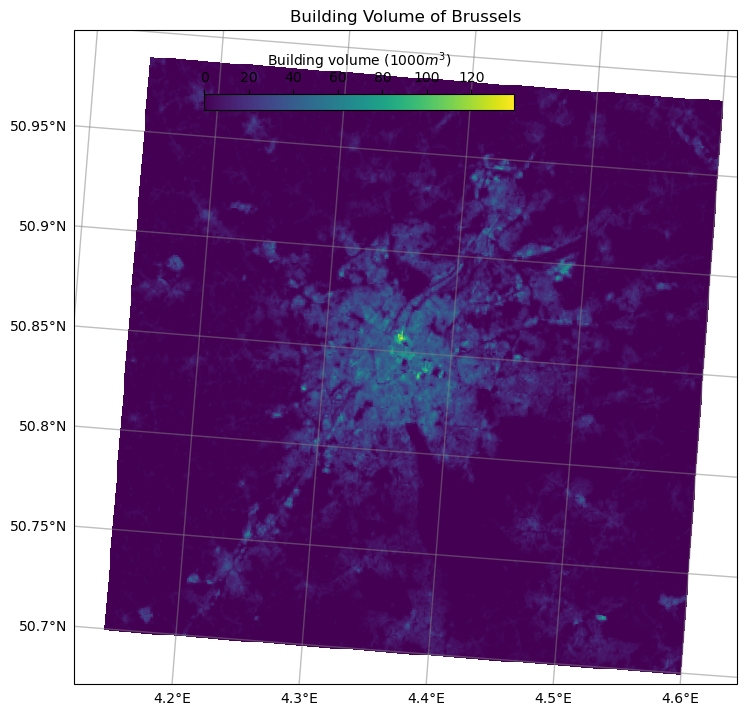

In [3]:
#### Open the netCDF file
ncfile5 = netCDF4.Dataset('./data/meteorology/Brussels/Air_temp_brussels/tas_Brussels_UrbClim_2015_06_v1.0.nc',mode='r',format='NETCDF4_CLASSIC') 

x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]
lons = ncfile5.variables['longitude'][:]
lats = ncfile5.variables['latitude'][:]
extent_meteo3035 = [y.min(), y.max(), x.min(), x.max() ]
extent_meteo4326 = [lats.min(), lats.max(), lons.min(), lons.max() ]
print('extent_meteo3035: ',extent_meteo3035)
print('extent_meteo4326: ',extent_meteo4326)
ncfile5.close()

# Overlay the GeoTIFF file on the map
src = rasterio.open('./data/3D_city/GHS_BUILT_V_E2010_GLOBE_R2023A_4326_3ss_V1_0_R4_C19.tif')#4326
# Read the image data from the GeoTIFF file
image = src.read()[0]
print(src.crs)
print(src.width)
print(src.height)
extent_lulc4326 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
y_int4326 = (src.bounds.top - src.bounds.bottom) / src.height
x_int4326 = (src.bounds.right - src.bounds.left) / src.width
print('extent_lulc4326: ',extent_lulc4326)
print('y_int4326, x_int4326: ', y_int4326, x_int4326)


deg = 1200#interval in 1 degree
clip = [ int(np.floor((extent_lulc4326[3]-extent_meteo4326[1])*deg)), int(np.ceil((extent_lulc4326[3]-extent_meteo4326[0])*deg)),
        int(np.floor((extent_meteo4326[2]-extent_lulc4326[0])*deg)), int(np.ceil((extent_meteo4326[3]-extent_lulc4326[0])*deg))]
print('clip',clip)
print('image.shape: ',image.shape)
data2 = image[clip[0]:clip[1], clip[2]:clip[3]]/1000
print('data2.shape: ',data2.shape)

# Create a figure and axis with specified CRS
projection = ccrs.epsg(3035) #ccrs.Mollweide()
fig, ax = plt.subplots(subplot_kw={'projection': projection},figsize=(10, 10))

# Add coastlines and title
#ax.coastlines()
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
plt.title('Building Volume of Brussels')
print('extent_meteo4326',extent_meteo4326)
# Add colorbar
im = ax.imshow(data2, extent=[extent_meteo4326[2], extent_meteo4326[3], extent_meteo4326[0],extent_meteo4326[1]], transform=ccrs.PlateCarree(), cmap='viridis', origin='upper')
plt.colorbar(im, ax=ax,location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.8), label='Building volume '+'$(1000 m^{3})$')
# Add coastlines
#ax.coastlines()
# Add gridlines with correct longitude and latitude markings
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Show the plot
plt.show()

In [9]:
#### Open the netCDF file
ncfile5 = netCDF4.Dataset('./data/meteorology/Brussels/Air_temp_brussels/tas_Brussels_UrbClim_2015_06_v1.0.nc',mode='r',format='NETCDF4_CLASSIC') 

x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]
lons = ncfile5.variables['longitude'][:]
lats = ncfile5.variables['latitude'][:]
extent_meteo3035 = [y.min(), y.max(), x.min(), x.max() ]
extent_meteo4326 = [lats.min(), lats.max(), lons.min(), lons.max() ]
print('extent_meteo3035: ',extent_meteo3035)
print('extent_meteo4326: ',extent_meteo4326)
ncfile5.close()

# Overlay the GeoTIFF file on the map
src = rasterio.open('./data/3D_city/GHS_BUILT_V_E2010_GLOBE_R2023A_4326_3ss_V1_0_R4_C19.tif')#4326
# Read the image data from the GeoTIFF file
image = src.read()[0]
print(src.crs)
print(src.width)
print(src.height)
extent_lulc4326 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
y_int4326 = (src.bounds.top - src.bounds.bottom) / src.height
x_int4326 = (src.bounds.right - src.bounds.left) / src.width
print('extent_lulc4326: ',extent_lulc4326)
print('y_int4326, x_int4326: ', y_int4326, x_int4326)

clip_3035, clip, y_int, x_int = helpers.clip_city(extent_meteo3035, extent_meteo3035, 10) 
print('clip_3035',clip_3035)

deg = 1200#interval in 1 degree
clip = [ int(np.floor((extent_lulc4326[3]-extent_meteo4326[1])*deg)), int(np.ceil((extent_lulc4326[3]-extent_meteo4326[0])*deg)),
        int(np.floor((extent_meteo4326[2]-extent_lulc4326[0])*deg)), int(np.ceil((extent_meteo4326[3]-extent_lulc4326[0])*deg))]
print('clip',clip)
print('image.shape: ',image.shape)
Ys_lulc4326, Xs_lulc4326 = helpers.GetCentroids(yLims=[src.bounds.bottom, src.bounds.top], xLims=[src.bounds.left, src.bounds.right], shapeYX=(src.height,src.width))
Ys_lulc3035, Xs_lulc3035 = helpers.GetGrids(yLims=[clip_3035[0], clip_3035[1]], xLims=[clip_3035[2], clip_3035[3]], shapeYX=(x_int,y_int))
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)
Ys_lulc4326 = Ys_lulc4326[::-1][clip[0]-10:clip[1]+10]
Xs_lulc4326 = Xs_lulc4326[clip[2]-10:clip[3]+10]
#print(Ys_lulc4326)
#print(Xs_lulc4326)

date_list = ['2005', '2010', '2015', '2020']
bv_val = np.zeros(( len(date_list), y_int, x_int))
bv_count = bv_val.copy()
bv_nc = bv_val.copy()
print(bv_val.shape)



extent_meteo3035:  [3081555.0, 3111555.0, 3910061.0, 3940061.0]
extent_meteo4326:  [50.698475, 50.98796, 4.1430073, 4.6004033]
EPSG:4326
12000
12000
extent_lulc4326:  [-0.007916644272569329, 9.99208331611786, 49.09958333863592, 59.09958329838777]
y_int4326, x_int4326:  0.0008333333299793211 0.0008333333300325358
clip_3035 [3082000, 3111000, 3911000, 3940000]
clip [9733, 10082, 4981, 5530]
image.shape:  (12000, 12000)
(4, 29, 29)


In [10]:
l=0
for d in date_list:
    src = rasterio.open('./data/3D_city/GHS_BUILT_V_E'+d+'_GLOBE_R2023A_4326_3ss_V1_0_R4_C19.tif')
    image = src.read()[0]
    print(d)
    image = image[clip[0]-10:clip[1]+10, clip[2]-10:clip[3]+10]
    print('image.shape',image.shape)
    for y_4326 in Ys_lulc4326:

        for x_4326 in Xs_lulc4326:
            x_3035, y_3035 = transformer.transform(x_4326, y_4326)
            if y_3035 <= np.min(Ys_lulc3035) or y_3035 >= np.max(Ys_lulc3035) or x_3035 <= np.min(Xs_lulc3035) or x_3035 >= np.max(Xs_lulc3035):
                a=0
            else:
                l=l+1
                y_index3035 = np.searchsorted(Ys_lulc3035, y_3035) - 1
                x_index3035 = np.searchsorted(Xs_lulc3035, x_3035) - 1
                y_index4326 = np.where(Ys_lulc4326 == y_4326)[0][0]
                x_index4326 = np.where(Xs_lulc4326 == x_4326)[0][0]

                bv_val[date_list.index(d)][y_index3035, x_index3035] = bv_val[date_list.index(d)][y_index3035, x_index3035] + image[y_index4326, x_index4326]
                bv_count[date_list.index(d)][y_index3035, x_index3035] = bv_count[date_list.index(d)][y_index3035, x_index3035] + 1

#no need to take the average. The building volume add on/accumulate
bv_val = bv_val[:,::-1,:] ###!!!flip y axis for nc file
src.close()

2005
image.shape (369, 569)
2010
image.shape (369, 569)
2015
image.shape (369, 569)
2020
image.shape (369, 569)


In [11]:
#creat grid indexes with centroid of the grids
y_new = np.array((np.arange(clip_3035[0]+500, clip_3035[1]+500, 1000)))[::-1]
x_new = np.array((np.arange(clip_3035[2]+500, clip_3035[3]+500, 1000)))
print(y_new)
print(y_new.shape)
print(x_new)
print(x_new.shape)
lons = np.zeros((y_new.shape[0], x_new.shape[0]))
lats = np.zeros((y_new.shape[0], x_new.shape[0]))
EPSG_from = 3035
EPSG_to = 4326
crs_from = pyproj.CRS('EPSG:'+str(EPSG_from))  # ETRS89 / LAEA Europe
crs_to = pyproj.CRS('EPSG:'+str(EPSG_to))    # WGS 84

# Create a transformer to convert coordinates
transformer = pyproj.Transformer.from_crs(crs_from, crs_to, always_xy=True)

for x in x_new:
    for y in y_new:
        x_loc = np.where(x_new==x)[0]
        y_loc = np.where(y_new==y)[0]
        lons[y_loc, x_loc], lats[len(y_new) - y_loc-1, x_loc] = transformer.transform(x, y)
print(lons)
print(lats)

[3110500 3109500 3108500 3107500 3106500 3105500 3104500 3103500 3102500
 3101500 3100500 3099500 3098500 3097500 3096500 3095500 3094500 3093500
 3092500 3091500 3090500 3089500 3088500 3087500 3086500 3085500 3084500
 3083500 3082500]
(29,)
[3911500 3912500 3913500 3914500 3915500 3916500 3917500 3918500 3919500
 3920500 3921500 3922500 3923500 3924500 3925500 3926500 3927500 3928500
 3929500 3930500 3931500 3932500 3933500 3934500 3935500 3936500 3937500
 3938500 3939500]
(29,)
[[4.16462758 4.1788225  4.19301782 4.20721355 4.22140967 4.2356062
  4.24980312 4.26400044 4.27819815 4.29239626 4.30659476 4.32079366
  4.33499295 4.34919263 4.3633927  4.37759315 4.391794   4.40599523
  4.42019685 4.43439886 4.44860125 4.46280402 4.47700718 4.49121071
  4.50541463 4.51961893 4.5338236  4.54802865 4.56223408]
 [4.16575555 4.17994776 4.19414037 4.20833338 4.22252679 4.2367206
  4.25091481 4.26510941 4.27930441 4.2934998  4.30769559 4.32189177
  4.33608834 4.3502853  4.36448265 4.37868039 4.39

(4, 29, 29)


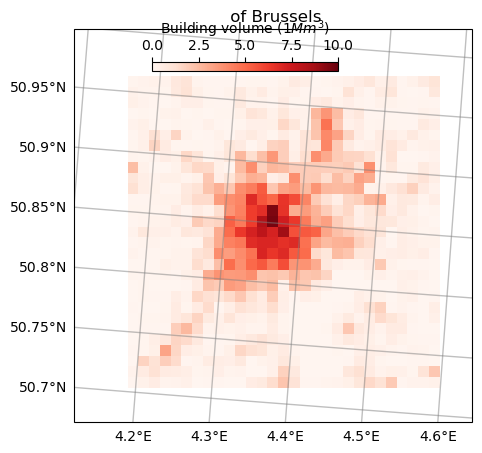

In [13]:
# Create a figure and axis with specified CRS
projection = ccrs.epsg(3035)
fig, ax = plt.subplots(subplot_kw={'projection': projection},figsize=(6, 6))
i=3

plt.title(' of Brussels')
print(bv_nc.shape)

# Plot the data using pcolormesh
#Ys, Xs = helpers.GetCentroids(yLims=[clip_3035[0], clip_3035[1]], xLims=[clip_3035[2], clip_3035[3]], shapeYX=(clip_3035[1]- clip_3035[0],clip_3035[3]- clip_3035[2]))
#Ys = Ys[::-1]
plt.pcolormesh(x_new, y_new, bv_val[i][:,:]/1000000, cmap='Reds').set_clim(0,10)
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.colorbar(label='Building volume '+'$(1 Mm^{3})$',location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.7))


# Show the plot
plt.show()

In [14]:
#save the results in a nc file
OutputFile = netCDF4.Dataset('./data/3D_city/Building_volume_brussels.nc', "w", format="NETCDF4")

len1 = OutputFile.createDimension("x", x_int)
len2 = OutputFile.createDimension("y", y_int)

y = y_new.copy()
x = x_new.copy()

var_x = OutputFile.createVariable("x", "f4", ("x",))
var_y = OutputFile.createVariable("y", "f4", ("y",))
var_lons = OutputFile.createVariable('longitude', "f4", ("y","x"))
var_lats = OutputFile.createVariable('latitude', "f4", ("y","x"))
for i in range(len(date_list)):
    var = OutputFile.createVariable(date_list[i], "f4", ("y","x"))
    var[:] = bv_val[i]

var_x[:] = x
var_y[:] = y
var_lons[:] = lons
var_lats[:] = lats
OutputFile.close()

In [98]:
OutputFile.close()

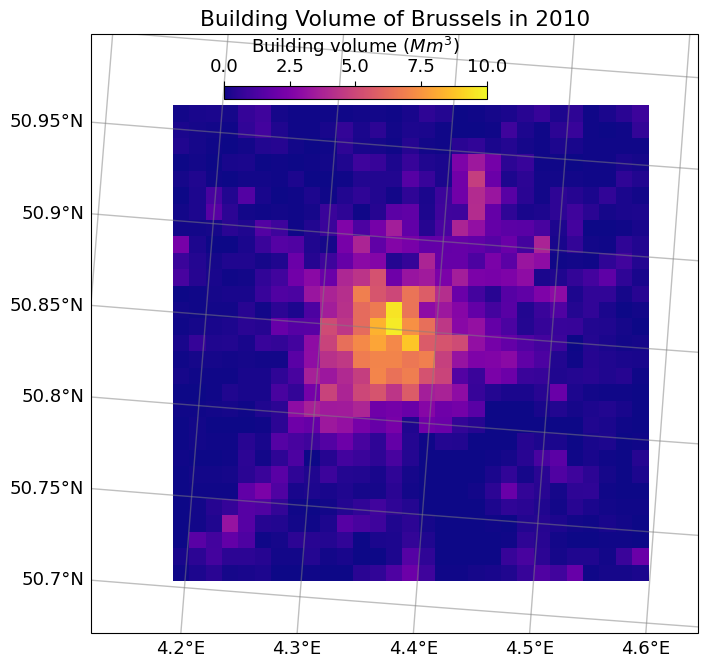

In [16]:
# Create a figure and axis with specified CRS
ncfile5 = netCDF4.Dataset('./data/3D_city/Building_volume_brussels.nc',mode='r',format='NETCDF4_CLASSIC')

i=1
date_list = ['2005', '2010', '2015', '2020']
NDVI = ncfile5.variables[date_list[i]][:,:].data/1000000
lons = ncfile5.variables['longitude'][:]
lats = ncfile5.variables['latitude'][:]
x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]
extent_3035 = [y.min()-500, y.max()+500, x.min()-500, x.max()+500 ]

plt.figure(figsize=(8.48, 9.15))
plt.rcParams.update({'font.size': 13})
ax = plt.axes(projection=ccrs.epsg(3035))
plt.title('Building Volume of Brussels in '+date_list[i])
#print(NDVI.shape)


# Plot the data using pcolormesh

plt.pcolormesh(x, y, NDVI, cmap='plasma').set_clim(0,10)
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.colorbar(label='Building volume '+'$(Mm^{3})$',location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.7))

#plt.savefig('./data/BuildingVolume.png', transparent=True, bbox_inches='tight', dpi=300)
# Show the plot
plt.show()
ncfile5.close()